In [ ]:
import sys
sys.path.append('..')

In [ ]:
import pandas as pd
from os.path import join as pjoin
from utils.misc import load_config

In [ ]:
import numpy as np
import pandas as pd
from os.path import join as pjoin

import torch

from sklearn.model_selection import train_test_split

from datasets.utils import create_patches, scale_data

def prepare_data(config, X, Y, blind = False):
    print("Preparing the data...")

    # Load the parameters from the config file
    data_config = config['data']
    root = config['root']

    # Get the unique well names
    well_names = X.UWI.unique()

    # Drop the columns that are not needed in the training
    X.drop(data_config['drop_columns'], axis=1, inplace=True)

    # Scale the data
    X = scale_data(X, data_config)

    # check if the data is patch based, if yes, create patches else model will be trained on the point data
    if data_config['patch_based']:

        # Create patches from the data
        num_features = X.shape[1] - 1
        x_patches, y_patches = create_patches(X, Y, well_names, data_config, num_features)

        # Get the number of classes
        num_classes = len(np.unique(y_patches))

        if not blind:
            # Split the data into train and validation
            (
                x_train, 
                x_val, 
                y_train, 
                y_val
            ) = train_test_split(
                x_patches, 
                y_patches, 
                test_size=data_config['split_size'], 
                random_state=config['random_state']
            )

            # Convert the data to PyTorch tensors
            x_train = torch.tensor(x_train).float()
            y_train = torch.tensor(y_train)
            x_val = torch.tensor(x_val).float()
            y_val = torch.tensor(y_val)
        else:
            x_train = torch.tensor(x_patches).float()
            y_train = torch.tensor(y_patches)
            x_val = None
            y_val = None
    else:
        # drop the well name column
        X = X.drop([data_config['well_name_column']], 
                   axis=1)
        
        # Get the number of classes
        num_classes = len(np.unique(Y))

        # Split the data into train and validation
        (
            x_train, 
            x_val, 
            y_train, 
            y_val
        ) = train_test_split(
            X, 
            Y, 
            test_size=data_config['split_size'], 
            random_state=config['random_state']
        )

    print(f"Number of classes: {num_classes} and shape of x_train: {x_train.shape}")
    return x_train, x_val, y_train, y_val, num_classes

import hydra
import os
import numpy as np
from time import time
from os.path import join as pjoin
from omegaconf import DictConfig

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from datasets import data_preparation
from utils.misc import (add_to_config, 
                        current_time, 
                        copy_running_code, 
                        plot_loss_accuracy_curve, 
                        plot_confusion_matrix, 
                        save_best_checkpoint, 
                        save_hparams,
                        load_lora
                        )
from engine.policy import validation_engine as blind_engine

In [ ]:
exp_path = '../results/policy/dl.vit/2023-08-24 00Hr 11Min 50Sec IST+0530'
config = load_config('.', exp_path, 'hyperparameters.yaml')

In [ ]:
root = '../data/filtered'

In [ ]:
xPath = pjoin(root, 'X.h5')
yPath = pjoin(root, 'Y.h5')

In [ ]:
X_all = pd.read_hdf(xPath)
Y_all = pd.read_hdf(yPath)

In [ ]:
from model.vit import build_model
from engine.policy import train
from tqdm import tqdm

In [ ]:
all_blind = {}
for blind_well in tqdm(X_all.UWI.unique(), total = len(X_all.UWI.unique()), desc = 'Blind well'):
    blind_X = X_all[X_all.UWI == blind_well]
    blind_Y = Y_all[X_all.UWI == blind_well]

    Y = Y_all[X_all.UWI != blind_well]
    X = X_all[X_all.UWI != blind_well]

    x_train, x_val, y_train, y_val, num_classes = prepare_data(config, X, Y, blind = False)
    x_blind, _, y_blind, _, _ = prepare_data(config, blind_X, blind_Y, blind = True)


    data_config = config['data']
    trainer_config = config['trainer']
    random_state = config['random_state']
    model_config = config['model']
    callbacks_config = config['callbacks']

        #set random seed
    torch.manual_seed(random_state)
    np.random.seed(random_state)

    train_dataset = TensorDataset(x_train, 
                                    y_train)
    train_loader = DataLoader(train_dataset, 
                                batch_size=trainer_config['batch_size'], 
                                shuffle=True)

    val_dataset = TensorDataset(x_val, 
                                    y_val)
    val_loader = DataLoader(val_dataset, 
                                batch_size=trainer_config['batch_size'], 
                                shuffle=True)
    
    blind_dataset = TensorDataset(x_blind,
                                    y_blind)
    blind_loader = DataLoader(blind_dataset,
                                batch_size=trainer_config['batch_size'],
                                shuffle=True)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        # Define the loss function and optimizer
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(data_config['class_weights']).float().to(device))

        # Training loop
    num_epochs = 2#trainer_config['epochs']
    
        # add new key to hydra config
    data_config['num_features'] = x_train.shape[-1]
    trainer_config['device'] = str(device)

    model = build_model(config)
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=trainer_config['lr'])

    (
        train_losses, 
        val_losses, 
        train_accuracies, 
        val_accuracies, 
        best_epoch, 
        best_loss,
        best_cm_val,
        best_cm,
        model_chkpt,
        optim_chkpt
    ) = train(
        num_epochs, 
        model, 
        train_loader, 
        val_loader, 
        criterion, 
        optimizer,
        callbacks_config['early_stopping_tolerance'],
        device,
    )
    model.load_state_dict(model_chkpt)
    blind_loss, blind_accuracy, blind_cm = blind_engine(1,
                                                    model,
                                                    blind_loader,
                                                    criterion,
                                                    1,
                                                    device)
    all_blind[blind_well] = blind_accuracy
    break
#save all_blind
# np.save('all_blind.npy', all_blind)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = np.load('../all_blind.npy', allow_pickle=True)

In [3]:
data = data.item()

In [4]:
len(data)

1048

In [8]:
threshold = 75

In [9]:
{key: value for key, value in data.items() if value > threshold}

{'AA-07-35-093-12W4-0': 85.18518575032552,
 'AA-03-06-091-07W4-0': 76.33333333333333,
 '00-07-06-079-03W4-0': 83.13580322265625,
 'AA-04-04-093-09W4-0': 81.8181864420573,
 'AA-16-23-093-12W4-0': 78.30303446451823,
 'AA-10-01-098-08W4-0': 78.0,
 'AA-08-18-096-16W4-0': 75.46666971842448}

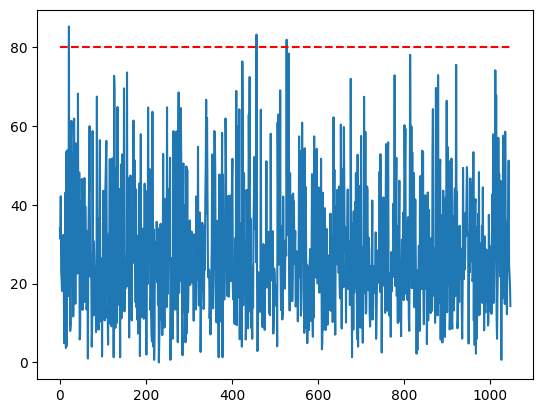

In [7]:
plt.plot(data.values())
plt.hlines(threshold, 0, len(data), colors='r', linestyles='dashed')
plt.show()